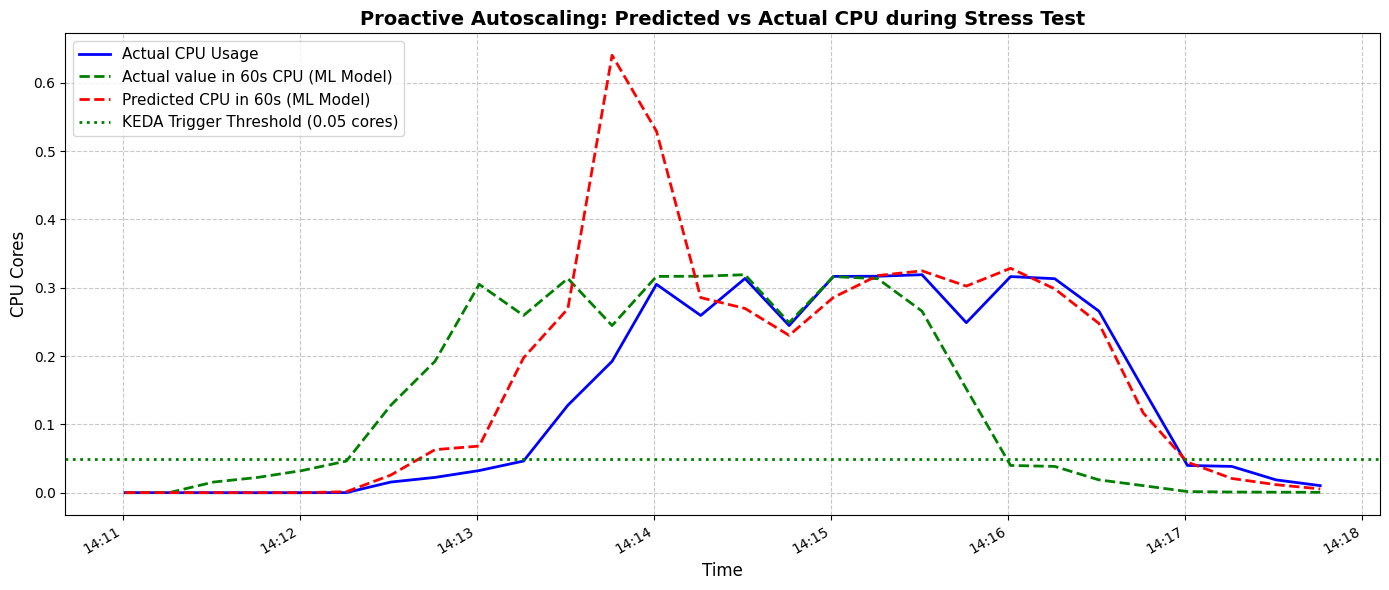

✅ Успішно завантажено 28 записів та побудовано графік!


In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Задаємо параметри для API
# Заміни URL на той, де крутиться твій FastAPI (наприклад, http://localhost:8000 або інший)
API_URL = "http://localhost:5000/metrics/history/range" # додай префікс /api/..., якщо він у тебе є

# Задаємо часове вікно (в форматі ISO 8601, як очікує FastAPI DateTime)
payload = {
    "start_time": "2026-03-12T14:11:00Z",  # Зміни на час твого тесту
    "end_time": "2026-03-12T14:18:00Z",
    "resource": "cpu"
}

# 2. Робимо запит до API
# ⚠️ ВАЖЛИВО: Оскільки в коді роутера ти приймаєш Pydantic модель (MetricHistoryRangeRead) 
# без Depends(), FastAPI швидше за все очікує ці дані в ТІЛІ запиту (JSON), 
# хоча це і GET-запит. Тому передаємо через `json=`, а не `params=`.
response = requests.get(API_URL, json=payload)

if response.status_code == 200:
    data = response.json()
    
    # 3. Перетворюємо список словників у Pandas DataFrame
    df = pd.DataFrame(data)
    
    if not df.empty:
        # Переконуємось, що час у правильному форматі
        df['ts'] = pd.to_datetime(df['ts'])

        # 4. Малюємо академічний графік
        plt.figure(figsize=(14, 6))

        # Синя лінія - реальний CPU
        plt.plot(df['ts'], df['input_value'], label='Actual CPU Usage', color='blue', linewidth=2)

        plt.plot(df['ts'], df['actual_value'], label='Actual value in 60s CPU (ML Model)', color='green', linestyle='--', linewidth=2)

        # Червона пунктирна лінія - прогноз "Снайпера"
        plt.plot(df['ts'], df['predicted_value'], label='Predicted CPU in 60s (ML Model)', color='red', linestyle='--', linewidth=2)
        
        # Зелена лінія - поріг, коли прокидається KEDA
        plt.axhline(y=0.05, color='green', linestyle=':', linewidth=2, label='KEDA Trigger Threshold (0.05 cores)')

        # Оформлення
        plt.title('Proactive Autoscaling: Predicted vs Actual CPU during Stress Test', fontsize=14, fontweight='bold')
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('CPU Cores', fontsize=12)
        plt.legend(loc='upper left', fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.7)

        # Форматуємо час на осі X 
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.gcf().autofmt_xdate()

        # Зберігаємо графік для диплома у високій якості
        plt.tight_layout()
        plt.savefig('proactive_test_cpu_graph.png', dpi=300)
        plt.show()
        
        print(f"✅ Успішно завантажено {len(df)} записів та побудовано графік!")
    else:
        print("⚠️ API повернуло порожній список. Перевір start_time та end_time!")
else:
    print(f"❌ Помилка API: {response.status_code} - {response.text}")

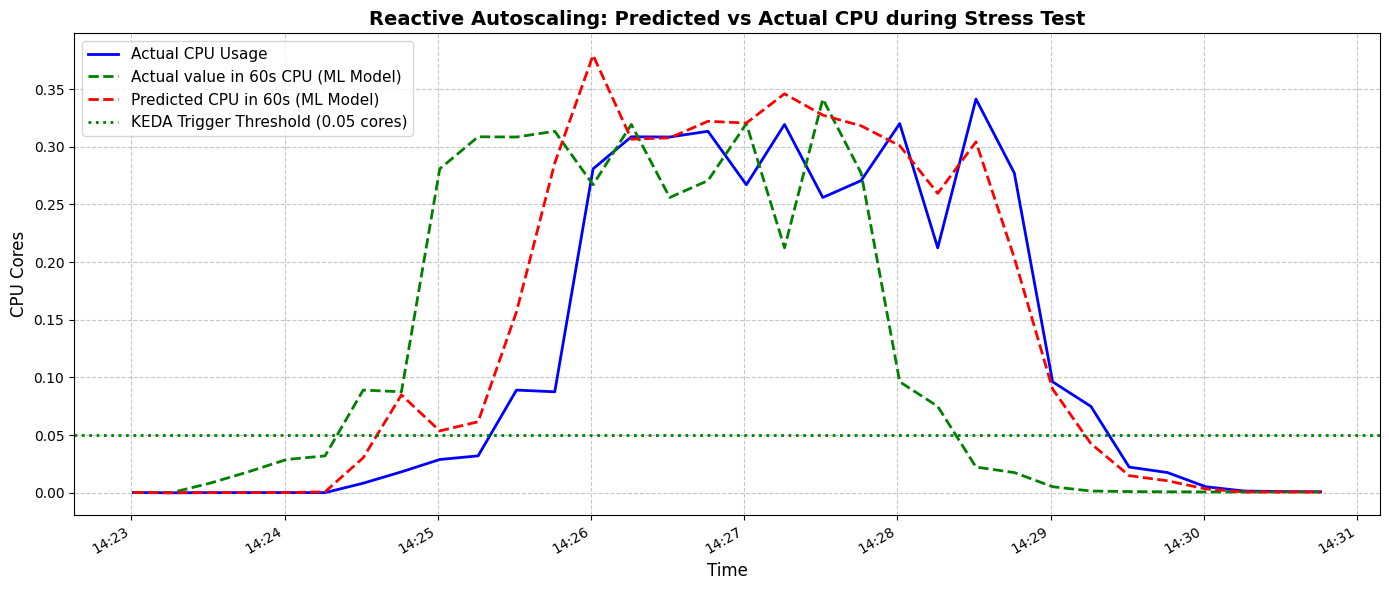

✅ Успішно завантажено 32 записів та побудовано графік!


In [5]:
# Задаємо часове вікно (в форматі ISO 8601, як очікує FastAPI DateTime)
payload = {
    "start_time": "2026-03-12T14:23:00Z",  # Зміни на час твого тесту
    "end_time": "2026-03-12T14:31:00Z",
    "resource": "cpu"
}

# 2. Робимо запит до API
# ⚠️ ВАЖЛИВО: Оскільки в коді роутера ти приймаєш Pydantic модель (MetricHistoryRangeRead) 
# без Depends(), FastAPI швидше за все очікує ці дані в ТІЛІ запиту (JSON), 
# хоча це і GET-запит. Тому передаємо через `json=`, а не `params=`.
response = requests.get(API_URL, json=payload)

if response.status_code == 200:
    data = response.json()
    
    # 3. Перетворюємо список словників у Pandas DataFrame
    df = pd.DataFrame(data)
    
    if not df.empty:
        # Переконуємось, що час у правильному форматі
        df['ts'] = pd.to_datetime(df['ts'])

        # 4. Малюємо академічний графік
        plt.figure(figsize=(14, 6))

        # Синя лінія - реальний CPU
        plt.plot(df['ts'], df['input_value'], label='Actual CPU Usage', color='blue', linewidth=2)

        plt.plot(df['ts'], df['actual_value'], label='Actual value in 60s CPU (ML Model)', color='green', linestyle='--', linewidth=2)

        # Червона пунктирна лінія - прогноз "Снайпера"
        plt.plot(df['ts'], df['predicted_value'], label='Predicted CPU in 60s (ML Model)', color='red', linestyle='--', linewidth=2)
        
        # Зелена лінія - поріг, коли прокидається KEDA
        plt.axhline(y=0.05, color='green', linestyle=':', linewidth=2, label='KEDA Trigger Threshold (0.05 cores)')

        # Оформлення
        plt.title('Reactive Autoscaling: Predicted vs Actual CPU during Stress Test', fontsize=14, fontweight='bold')
        plt.xlabel('Time', fontsize=12)
        plt.ylabel('CPU Cores', fontsize=12)
        plt.legend(loc='upper left', fontsize=11)
        plt.grid(True, linestyle='--', alpha=0.7)

        # Форматуємо час на осі X 
        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        plt.gcf().autofmt_xdate()

        # Зберігаємо графік для диплома у високій якості
        plt.tight_layout()
        plt.savefig('proactive_test_cpu_graph.png', dpi=300)
        plt.show()
        
        print(f"✅ Успішно завантажено {len(df)} записів та побудовано графік!")
    else:
        print("⚠️ API повернуло порожній список. Перевір start_time та end_time!")
else:
    print(f"❌ Помилка API: {response.status_code} - {response.text}")

✅ Детальний графік перцентилів успішно збережено!


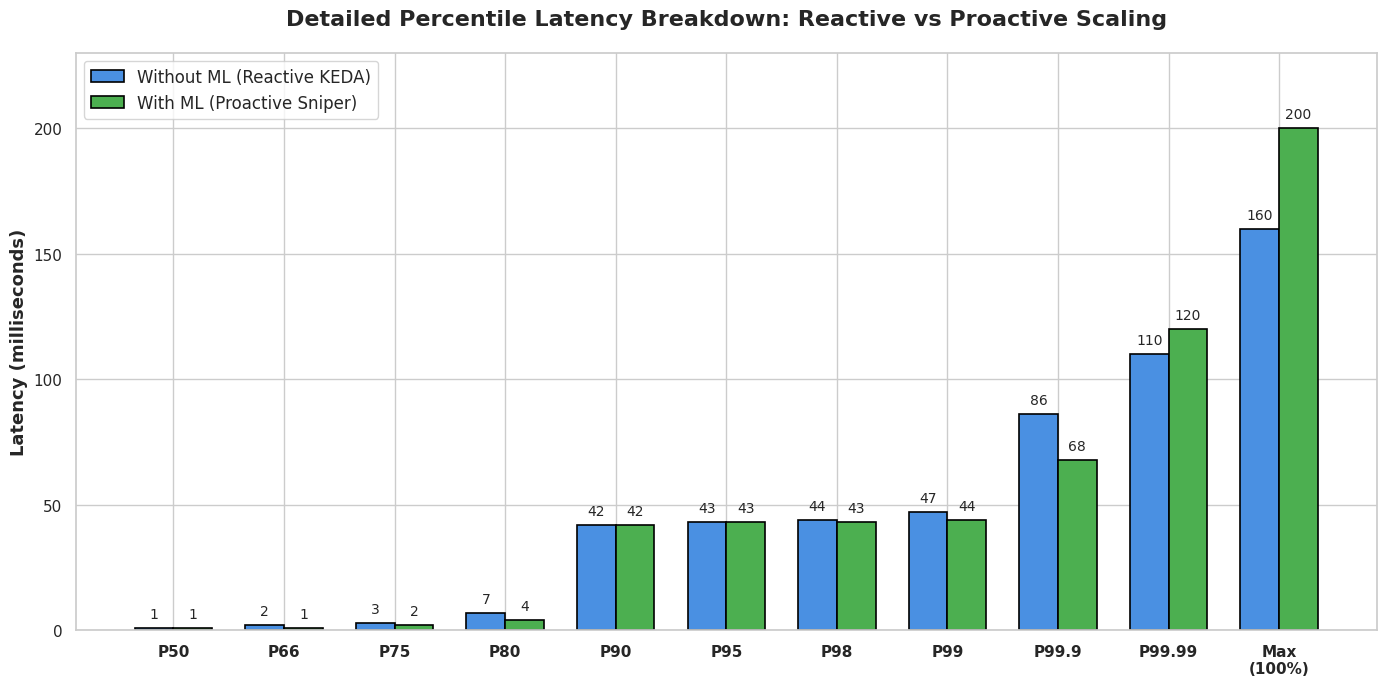

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Завантаження даних
file_with_ml = './test_data/with_ml_requests_short.csv'
file_without_ml = './test_data/without_ml_requests_short.csv'

df_with_ml = pd.read_csv(file_with_ml)
df_without_ml = pd.read_csv(file_without_ml)

# 2. Витягуємо загальну статистику (рядок Aggregated)
agg_with = df_with_ml[df_with_ml['Name'] == 'Aggregated'].iloc[0]
agg_without = df_without_ml[df_without_ml['Name'] == 'Aggregated'].iloc[0]

# 3. Усі перцентилі, які нам потрібні
percentiles = ['50%', '66%', '75%', '80%', '90%', '95%', '98%', '99%', '99.9%', '99.99%', '100%']
labels = ['P50', 'P66', 'P75', 'P80', 'P90', 'P95', 'P98', 'P99', 'P99.9', 'P99.99', 'Max\n(100%)']

values_with = [agg_with[p] for p in percentiles]
values_without = [agg_without[p] for p in percentiles]

# 4. Налаштування графіка
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

x = np.arange(len(percentiles))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

color_reactive = '#4A90E2' # Синій
color_proactive = '#4CAF50' # Зелений

rects1 = ax.bar(x - width/2, values_without, width, label='Without ML (Reactive KEDA)', 
                color=color_reactive, edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, values_with, width, label='With ML (Proactive Sniper)', 
                color=color_proactive, edgecolor='black', linewidth=1.2)

# Оформлення осей
ax.set_ylabel('Latency (milliseconds)', fontweight='bold', fontsize=13)
ax.set_title('Detailed Percentile Latency Breakdown: Reactive vs Proactive Scaling', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.legend(fontsize=12, loc='upper left')

# Автоматичні підписи над кожним стовпчиком
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=10)

autolabel(rects1)
autolabel(rects2)

# Додаємо трохи місця зверху для підписів
ax.set_ylim(0, max(max(values_without), max(values_with)) * 1.15)

plt.tight_layout()
plt.savefig('detailed_percentiles_plot.png', dpi=300)
print("✅ Детальний графік перцентилів успішно збережено!")
plt.show()

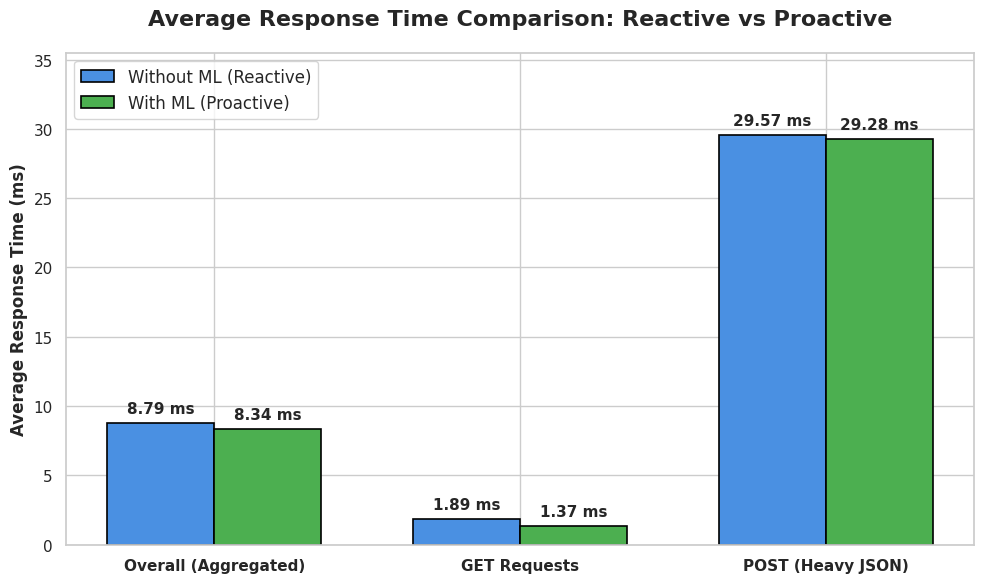

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Завантаження даних
file_with_ml = './test_data/with_ml_requests_short.csv'
file_without_ml = './test_data/without_ml_requests_short.csv'

df_with_ml = pd.read_csv(file_with_ml)
df_without_ml = pd.read_csv(file_without_ml)

# 2. Витягуємо Average Response Time для кожної категорії
categories = ['Aggregated', '/ (Brutal GET)', '/echo (Heavy POST)']
avg_with = []
avg_without = []

for cat in categories:
    val_with = df_with_ml[df_with_ml['Name'] == cat]['Average Response Time'].values[0]
    val_without = df_without_ml[df_without_ml['Name'] == cat]['Average Response Time'].values[0]
    avg_with.append(val_with)
    avg_without.append(val_without)

# 3. Налаштування графіка
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

color_reactive = '#4A90E2'
color_proactive = '#4CAF50'

rects1 = ax.bar(x - width/2, avg_without, width, label='Without ML (Reactive)', 
                color=color_reactive, edgecolor='black', linewidth=1.2)
rects2 = ax.bar(x + width/2, avg_with, width, label='With ML (Proactive)', 
                color=color_proactive, edgecolor='black', linewidth=1.2)

# Оформлення
ax.set_ylabel('Average Response Time (ms)', fontweight='bold', fontsize=12)
ax.set_title('Average Response Time Comparison: Reactive vs Proactive', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(['Overall (Aggregated)', 'GET Requests', 'POST (Heavy JSON)'], fontweight='bold')
ax.legend(fontsize=12, loc='upper left')

# Підписи значень
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f} ms',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=11, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

ax.set_ylim(0, max(max(avg_without), max(avg_with)) * 1.2)

plt.tight_layout()
plt.savefig('average_response_time_plot.png', dpi=300)
plt.show()